In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

c:\FAHEEM\My_Programs\RAG_Beginners\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Google api key is set


In [2]:
from typing import TypedDict, List, Annotated, Optional, Literal
from langchain_core.documents import Document
from pydantic import BaseModel, Field
from langgraph.graph.message import BaseMessage,add_messages

class llm_schema(BaseModel):
    question: Optional[str] = Field(description="question that needs to be answered")
    path: Optional[str] = Field(description="This holds path of the document the needs to be searched")
    task: Optional[Literal["save_data", "load_data"]] = Field(description="What operation to perform")
    web_link: Optional[str] = Field(description="Website link used by RAG to fecth info")

class graph_schema(TypedDict):
    query: Annotated[List[BaseMessage], add_messages]
    question: str
    documents: List[Document]
    result: str
    task: Literal["save_data", "load_data"]
    web_link: str
    path: Optional[str] = Field(
        description="path must be an exact filesystem path that user entered"
    )
    tool_calls: list
    conversation: Annotated[List[BaseMessage], add_messages]

llm_with_schema = llm.with_structured_output(llm_schema)
#Use this weblink https://www.gsmarena.com/oneplus_nord_ce6_lite_5g-14567.php and fetch important info about one plus nord ce6 lite

In [3]:
from typing import Optional, Literal
from langchain_core.tools import tool
from memory import LocalMemory
from tavily import TavilyClient
from semantic_memory import ConversationMemory
tavily_api_key = os.getenv("TAVILY_API_KEY")

tavily_client = TavilyClient(
    api_key=tavily_api_key
)

memory = LocalMemory()
semantic_memory = ConversationMemory()
@tool
def retriever_embedding_tool(question: str, path: Optional[str] = None, web_link: Optional[str] = None):
    """
    Retrieve relevant information from a specific local document.

    Use this tool when the user asks a question about a PDF, DOCX,
    TXT, Markdown file, or other provided document.

    Args:
        question: The exact question to answer using the document.
        path: The complete filesystem path to the document.
        web_link : Link that will be used to fecth information
    """
    if path:
        file_to_fectch = path
    elif web_link:
        file_to_fectch = web_link 
    else:
        raise ValueError(
            "Either 'path' or 'web_link' must be provided."
        )
        
    retrieve.file_loader(file_to_fectch)
    retrieve.text_splitting()
    retrieve.model_calling()

    result = retrieve.vector_embedding(question)

    return result

@tool
def memory_embedding_tool(task: Literal["save_data", "load_data"],
                        conversation: Optional[List] = None,
                        query: Optional[str] = None):
    """
    Tool used to retrieve information from stored information using memory vector embedding from local memory+
    Example: -"Remember this conversation."
            -"Save this conversation to memory."
            -"What did I previously discuss about RAG?"
            -"Do you remember my decision about LangGraph?"               
    Args:
        query: What to search for
        task: Request to save few conversation or load from memory
        conversation: the data that need to be stored 
    """
    if task == "save_data":

        if not conversation:
            raise ValueError(
                "conversation is required when task='save_data'"
            )

        semantic_memory.save_memory(conversation)

        return "Saved Conversation Successfully"

    else:

        if not query:
            raise ValueError(
                "query is required when task='load_data'"
            )

        return semantic_memory.search_memory(query)


@tool
def local_conversation_memory_tool(
    timestamp: Optional[str] = None,
    limit: Optional[int] = None,
    search_term: Optional[str] = None
):
    """
    Retrieve conversations from local conversation history.

    Use this tool when the user wants to inspect previous conversations.

    Examples:
    - "Show conversations from 8 Aug 2026"
    - "Show my last 5 conversations"
    - "Find previous conversations about LangGraph"

    Args:
        timestamp: Date/time filter.
        limit: Maximum number of conversations to return.
        search_term: Keyword or topic to filter conversations.
    """
    return memory.load_memory(
        timestamp=timestamp,
        limit=limit,
        search_term=search_term
    )

@tool
def web_search_tool(query: str, max_results: int = 5):
    """
    Search the web for current or external information.

    Use this tool when the user asks for information that may require
    current, recent, or internet-based knowledge.

    Examples:
    - "What is the latest LangGraph version?"
    - "Search for AI agent developer jobs in Dubai."
    - "What happened in the latest OpenAI announcement?"

    Args:
        query: The search query to perform.
        max_results: Maximum number of search results to return.
    """
    response = tavily_client.search(
        query=query,
        max_results=max_results
    )

    return response["results"]


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5119.31it/s]


In [4]:
tools = [retriever_embedding_tool, memory_embedding_tool, local_conversation_memory_tool, web_search_tool]

llm_with_tool = llm.bind_tools(tools)


In [ ]:
from RagIntegration import RagRetriever
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import ToolMessage
retrieve = RagRetriever()

def retriever_node(state: graph_schema) -> graph_schema:
    query = state['query']

    response = llm_with_tool.invoke(query)
    structured = llm_with_schema.invoke(query)
    
    return {
        "question": structured.question,
        "path": structured.path,
        "web_link": structured.web_link,
        "task": structured.task,
        "tool_calls": response.tool_calls
    }


def tool_node(state:graph_schema) -> graph_schema:
    tool_calls = state['tool_calls']
    tool_by_name = {tool.name: tool for tool in tools}

    documents = []
    result = ""
    for tool_call in tool_calls:
        tool = tool_by_name[tool_call["name"]]
        observation = tool_decision(state, tool, tool_call["name"])
        if isinstance(observation, list):
            documents.extend(observation)

        elif isinstance(observation, str):
            result = observation
    return {
        "documents": documents,
        "result": result
    }

def tool_decision(state:graph_schema, tool:str, tool_name: str):
    if tool_name == "retriever_embedding_tool":

        return tool.invoke({
            "question": state["question"],
            "path": state["path"],
            "web_link": state['web_link']
        })

    elif tool_name == "memory_embedding_tool":
        return tool.invoke({
            
            "task": state["task"],
            "conversation": state["conversation"],
            "query": state["question"]
        })
    
    elif tool_name == "web_search_tool":
        results =  tool.invoke({
            "query": state["question"]
        })

        return [
            Document(
                page_content=result["content"],
                metadata={
                    "title": result.get("title"),
                    "url": result.get("url")
                }
            )
            for result in results
        ]

    return []

def generator_node(state: graph_schema) -> graph_schema:
    question = state['question']
    document = state['documents']
    if state["task"] == "save_data":
        return {
            "result": state['result']
        }
        
    context = '\n\n'.join(docs.page_content for docs in document)

    prompt = ChatPromptTemplate.from_messages([
        ("system", """
            You are a helpful question-answering assistant.

Answer the user's question using only the information provided in the context.

Instructions:
- Use the context as your only source of factual information.
- Combine relevant information from multiple context documents when necessary.
- You may summarize, compare, and synthesize information from the context.
- Do not use your own knowledge or invent facts that are not supported by the context.
- If the context contains only partial information, answer only the part that is supported by the context.
- If the context does not contain enough information to answer the question, say:
  "I don't know based on the provided context."
- Give a clear and direct answer.
- Do not mention the retrieval process unless the user asks about it.
            Context: {context}
        """),
        ("user", """Question: {question}""")
    ])

    chain = prompt | llm

    result = chain.invoke({"context": context, "question": question})

    return {
        "result": result.content
    }

USER_AGENT environment variable not set, consider setting it to identify your requests.


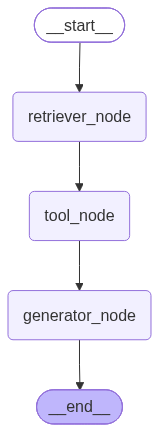

In [6]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("retriever_node", retriever_node)
graph.add_node("tool_node", tool_node)
graph.add_node("generator_node", generator_node)

graph.add_edge(START, "retriever_node")
graph.add_edge("retriever_node", "tool_node")
graph.add_edge("tool_node", "generator_node")
graph.add_edge("generator_node", END)

knowledge_assistant = graph.compile()
knowledge_assistant

In [7]:
#What is INVOLVE an AI powered on demand local service platform? examine a pdf named 29_Paper.pdf inside pdf folder of docs that is inside of C drive then Faheem then My_Programs Rag_Beginners
from langchain_core.messages import HumanMessage, AIMessage
from memory import LocalMemory
from datetime import datetime
memory = LocalMemory()

conversation = []
while True:
    query = input("Enter your request...(stop to end task)")

    if query.lower() == "stop":
        print("task ended")
        break

    conversation.append(HumanMessage(content=query))
    response = knowledge_assistant.invoke({
        "query": query,
        "question": "",
        "result": "",
        "path": "",
        "tool_calls": [],
        "document": [],
        "task": [],
        "conversation": conversation
    })
    tool_names = [
    call["name"]
    for call in response["tool_calls"]
]

    if "web_search_tool" in tool_names:
        save_data = memory.save_memory(
            response["question"],
            response["result"][0]["text"],
            datetime.now().isoformat()
        )
    elif "memory_embedding_tool" in tool_names:
        if response["task"] == 'save_data':
            save_data = memory.save_memory(
                        response["question"],
                        response["result"],
                        datetime.now().isoformat()
                    )
    else:
        save_data = memory.save_memory(
            response["question"],
            response["result"][0]["text"],
            datetime.now().isoformat()
        )

    if response["task"] == 'save_data':
        conversation.append(AIMessage(content=response["result"]))
    else:
        conversation.append(AIMessage(content=response["result"][0]["text"]))
    
    print(response)




{'query': [HumanMessage(content='Explain the job market scenario between AI Agent Development and Full Stack Development from internet', additional_kwargs={}, response_metadata={}, id='04f5f7ce-504a-4e58-935c-334b05eac968')], 'question': 'What is the job market outlook and comparison between AI Agent Development and Full Stack Development?', 'documents': [Document(metadata={'title': 'How AI-Assisted Development is Changing the 2026 Job Market', 'url': 'https://softssolutionservice.com/blog/how-ai-assisted-development-is-changing-the-2026-job-market'}, page_content='In the 2026 job market, the technical barrier to entry for building complex applications has shifted. Large Language Models (LLMs) and specialized AI agents now handle the boilerplate, unit tests, and even complex refactoring with high reliability. This change has forced a pivot in the required skill set for developers. Employers are no longer just looking for "coders"; they are looking for software architects and product en